# Figures of *A variational model of nonlinear poroelasticity*

Reproduces, inline, every figure and table in the paper that is generated from data:

| Paper item | Source data | Produced by |
|---|---|---|
| Figure 1 — accuracy | `data/accuracy/` | `run_accuracy.py` |
| Figure 3 — energy behaviour | `data/energy_blob/` | `run_energy_blob.py` |
| Figure 5 — footing stored energy | `data/footing/` | `run_footing.py` |
| Figures 6–8 — deformed domain | `data/footing_vtk/` | `run_footing.py` |
| Table 1 — footing summary | `data/footing/` | `run_footing.py` |

Figures 2 and 4 are TikZ schematics drawn directly in the manuscript; they have no
underlying computation and are not reproduced here.

Everything is bundled, so every cell below runs as-is. `data/footing_vtk/` ships only
the five snapshot times each footing figure actually shows (not the full ~43 GB of
field output `run_footing.py` writes); to view the full time resolution instead, set
`PF_VTK_ROOT` to a run directory it produced.

In [1]:
import os, csv, math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

HERE = os.getcwd()
DATA = os.path.join(HERE, "data")

# Bundled by default (5 snapshot times x 9 configs); point this at a full
# run_footing.py output directory instead to see the full time resolution.
VTK_ROOT = os.environ.get("PF_VTK_ROOT", os.path.join(DATA, "footing_vtk"))

def _num(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return v            # e.g. the footing 'phase' column, which is text

def read_csv(path):
    with open(path) as f:
        return [ {k: _num(v) for k, v in row.items()} for row in csv.DictReader(f) ]

def rates(vals, xs):
    """Successive-refinement rates log(e_i/e_{i+1}) / log(x_i/x_{i+1})."""
    return [math.log(vals[i]/vals[i+1]) / math.log(xs[i]/xs[i+1])
            for i in range(len(vals)-1)]

print("data:", os.path.relpath(DATA))
print("VTK_ROOT:", os.path.relpath(VTK_ROOT) if os.path.isdir(VTK_ROOT)
      else f"{VTK_ROOT} (not found - Figures 6-8 will be skipped)")

data: data
VTK_ROOT: data/footing_vtk


## Figure 1 — manufactured-solution accuracy

Errors are measured at the final time in the model's own energy quantities: the elastic
energy norm $\|e_{u}\|_E=(\int_\Omega \sigma_e(e_u):\nabla e_u)^{1/2}$ for displacement,
and $(\int_\Omega D_\omega)^{1/2}$ — the Bregman divergence of the fluid free energy —
for density. Both should show $O(h^2)$ and $O(\delta t^2)$.

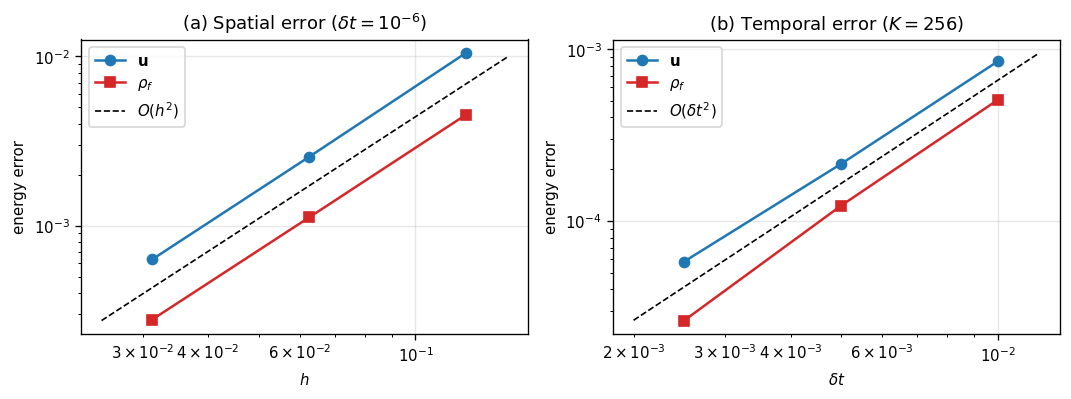

spatial   u: ['2.04', '2.01']   rho: ['2.02', '2.00']
temporal  u: ['1.99', '1.89']   rho: ['2.05', '2.22']


In [2]:
sp = read_csv(os.path.join(DATA, "accuracy", "spatial.csv"))
tp = read_csv(os.path.join(DATA, "accuracy", "temporal_K256.csv"))

h   = [r["h"]  for r in sp]; Eu_s = [r["En_u"] for r in sp]; Br_s = [r["Breg_rho"] for r in sp]
dts = [r["dt"] for r in tp]; Eu_t = [r["En_u"] for r in tp]; Br_t = [r["Breg_rho"] for r in tp]

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 3.4))

a.loglog(h, Eu_s, "o-", color="tab:blue", label=r"$\bf{u}$")
a.loglog(h, Br_s, "s-", color="tab:red",  label=r"$\rho_f$")
hh = np.array([min(h)*0.8, max(h)*1.2])
a.loglog(hh, 0.44*hh**2, "k--", lw=1, label=r"$O(h^2)$")
a.set_xlabel("$h$"); a.set_ylabel("energy error")
a.set_title(r"(a) Spatial error ($\delta t=10^{-6}$)"); a.legend()

b.loglog(dts, Eu_t, "o-", color="tab:blue", label=r"$\bf{u}$")
b.loglog(dts, Br_t, "s-", color="tab:red",  label=r"$\rho_f$")
tt = np.array([min(dts)*0.8, max(dts)*1.2])
b.loglog(tt, 6.6*tt**2, "k--", lw=1, label=r"$O(\delta t^2)$")
b.set_xlabel(r"$\delta t$"); b.set_ylabel("energy error")
b.set_title("(b) Temporal error ($K=256$)"); b.legend()

fig.tight_layout(); plt.show()

print(f"spatial   u: {['%.2f' % r for r in rates(Eu_s, h)]}   "
      f"rho: {['%.2f' % r for r in rates(Br_s, h)]}")
print(f"temporal  u: {['%.2f' % r for r in rates(Eu_t, dts)]}   "
      f"rho: {['%.2f' % r for r in rates(Br_t, dts)]}")

## Figure 3 — energy behaviour on the sealed blob

Left: the stored energy decays monotonically to equilibrium. Right: the cumulative
energy-law discrepancy
$\mathrm{DEFECT}(T)=|\mathcal{E}(T)-\mathcal{E}(0)+\delta t\sum_n D^n_{\mathrm{pred}}|$
converges at $O(\delta t^2)$, as implied by the $O(\delta t^3)$ per-step defect.

equilibrium level: 96.56% of initial


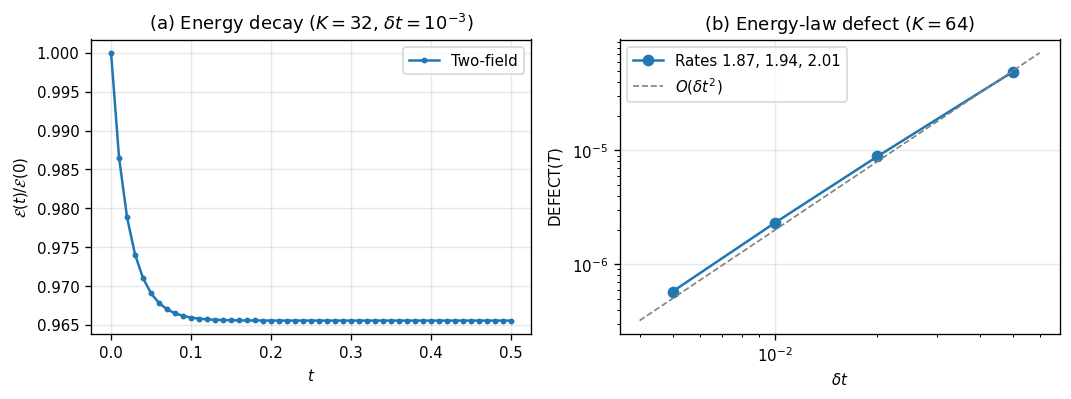

In [3]:
ts_path = os.path.join(DATA, "energy_blob", "energy_vs_time.csv")
df      = read_csv(os.path.join(DATA, "energy_blob", "defect_vs_dt.csv"))

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 3.4))

if os.path.exists(ts_path):
    ts = read_csv(ts_path)
    a.plot([r["time"] for r in ts], [r["energy_normalised"] for r in ts],
           "o-", ms=2.5, color="tab:blue", label="Two-field")
    a.set_xlabel("$t$"); a.set_ylabel(r"$\mathcal{E}(t)/\mathcal{E}(0)$")
    a.set_title("(a) Energy decay ($K=32$, $\\delta t=10^{-3}$)"); a.legend()
    print(f"equilibrium level: {ts[-1]['energy_normalised']*100:.2f}% of initial")
else:
    a.text(0.5, 0.5, "run:  python run_energy_blob.py timeseries",
           ha="center", va="center", transform=a.transAxes); a.set_axis_off()

d_dt = [r["dt"] for r in df]; d_v = [r["defect"] for r in df]
b.loglog(d_dt, d_v, "o-", color="tab:blue",
         label="Rates " + ", ".join(f"{r:.2f}" for r in rates(d_v, d_dt)))
tt = np.array([min(d_dt)*0.8, max(d_dt)*1.2])
b.loglog(tt, 2.0e-2*tt**2, "--", color="gray", lw=1, label=r"$O(\delta t^2)$")
b.set_xlabel(r"$\delta t$"); b.set_ylabel(r"DEFECT$(T)$")
b.set_title("(b) Energy-law defect ($K=64$)"); b.legend()

fig.tight_layout(); plt.show()

## Figure 5 — footing stored energy

Stored energy $\mathcal{E}(t)-\mathcal{E}(0)$ for the nine footing configurations
(three side-boundary treatments $\times$ three compressibility exponents). Energy
accumulates during the ramp $t\in[0,1]$ and relaxes during the hold $t\in[1,2]$ as the
system consolidates by drainage.

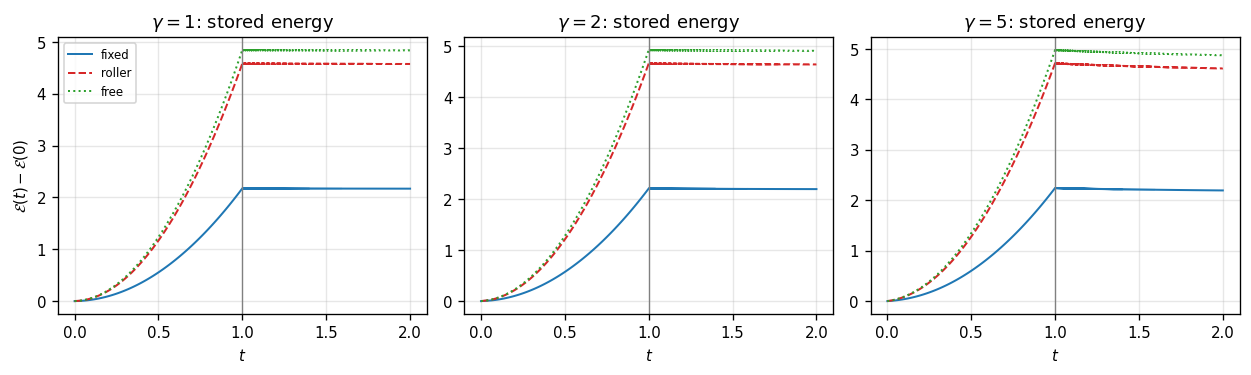

In [4]:
SIDES = [("clamped", "fixed", "tab:blue", "-"),
         ("sliding", "roller", "tab:red", "--"),
         ("free",    "free",  "tab:green", ":")]
GAMMAS = [1, 2, 5]

foot = {}
for s, _, _, _ in SIDES:
    for g in GAMMAS:
        foot[(s, g)] = read_csv(os.path.join(DATA, "footing", f"{s}_g{g}.csv"))

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), sharex=True)
for ax, g in zip(axes, GAMMAS):
    for s, lab, col, ls in SIDES:
        rows = foot[(s, g)]
        e0 = rows[0]["energy"]
        ax.plot([r["time"] for r in rows], [r["energy"]-e0 for r in rows],
                ls, color=col, lw=1.2, label=lab)
    ax.axvline(1.0, color="gray", lw=0.8)
    ax.set_title(rf"$\gamma={g}$: stored energy"); ax.set_xlabel("$t$")
axes[0].set_ylabel(r"$\mathcal{E}(t)-\mathcal{E}(0)$"); axes[0].legend(fontsize=7)
fig.tight_layout(); plt.show()

## Table 1 — footing summary

Stored energy $\Delta\mathcal{E}$ and fluid mass change $\Delta\mathcal{M}$ (units
$10^{-2}$) at the end of the ramp ($t=1$) and the end of the hold ($t=2$).

In [5]:
def at_time(rows, t):
    r = min(rows, key=lambda r: abs(r["time"] - t))
    return r["energy"] - rows[0]["energy"], r["mass"] - rows[0]["mass"]

print(f"{'gamma':>5} {'side':>7} {'dE(1)':>7} {'dE(2)':>7} {'dM(1)':>7} {'dM(2)':>7}")
print("-"*46)
for g in GAMMAS:
    for s, lab, _, _ in SIDES:
        rows = foot[(s, g)]
        dE1, dM1 = at_time(rows, 1.0)
        dE2, dM2 = at_time(rows, 2.0)
        print(f"{g:>5} {lab:>7} {dE1:>7.2f} {dE2:>7.2f} "
              f"{dM1*100:>7.2f} {dM2*100:>7.2f}")
print("\n(dM columns are x10^-2, matching the table in the paper)")

gamma    side   dE(1)   dE(2)   dM(1)   dM(2)
----------------------------------------------
    1   fixed    2.18    2.17    3.76    3.36
    1  roller    4.58    4.58    8.48    7.99
    1    free    4.85    4.84    8.97    8.45
    2   fixed    2.21    2.20    3.54    3.01
    2  roller    4.66    4.64    8.19    7.43
    2    free    4.92    4.91    8.65    7.85
    5   fixed    2.24    2.20    2.35    1.31
    5  roller    4.72    4.62    5.88    3.32
    5    free    4.98    4.88    6.18    3.49

(dM columns are x10^-2, matching the table in the paper)


## Figures 6–8 — deformed-domain evolution

The domain at physical scale, coloured by fluid density $\rho_f$ with a Darcy-flux
quiver overlay, at five equally spaced times, for each compressibility exponent. All
panels within a figure share the same axis limits, colour scale and quiver scale, as in
the paper. `data/footing_vtk/` bundles just these five snapshots per configuration
(displacement `u`, Darcy flux `q`, and density `rho`); set `PF_VTK_ROOT` to a full
`run_footing.py` output directory to use its full time resolution instead.

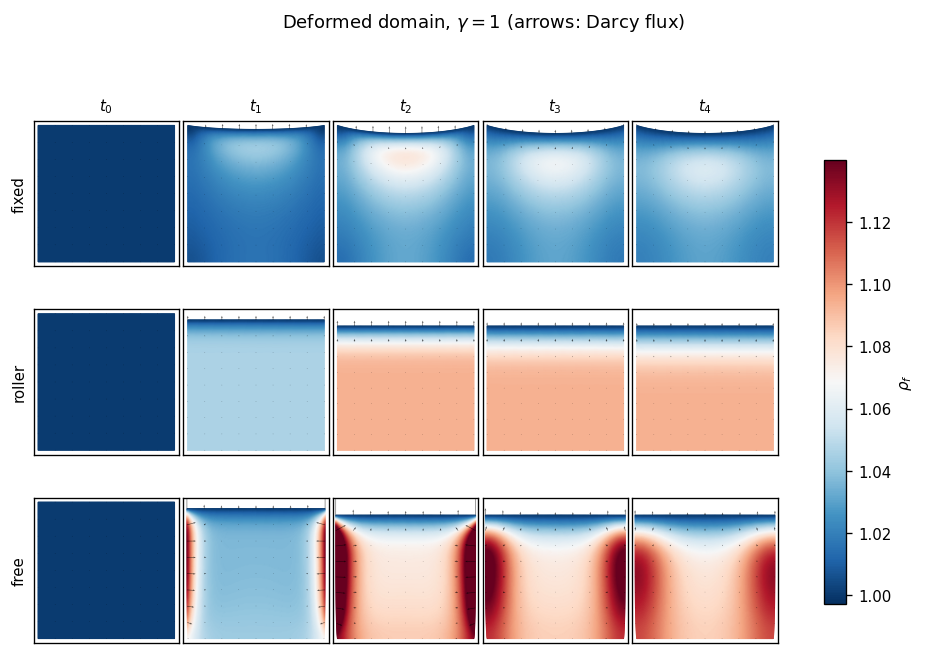

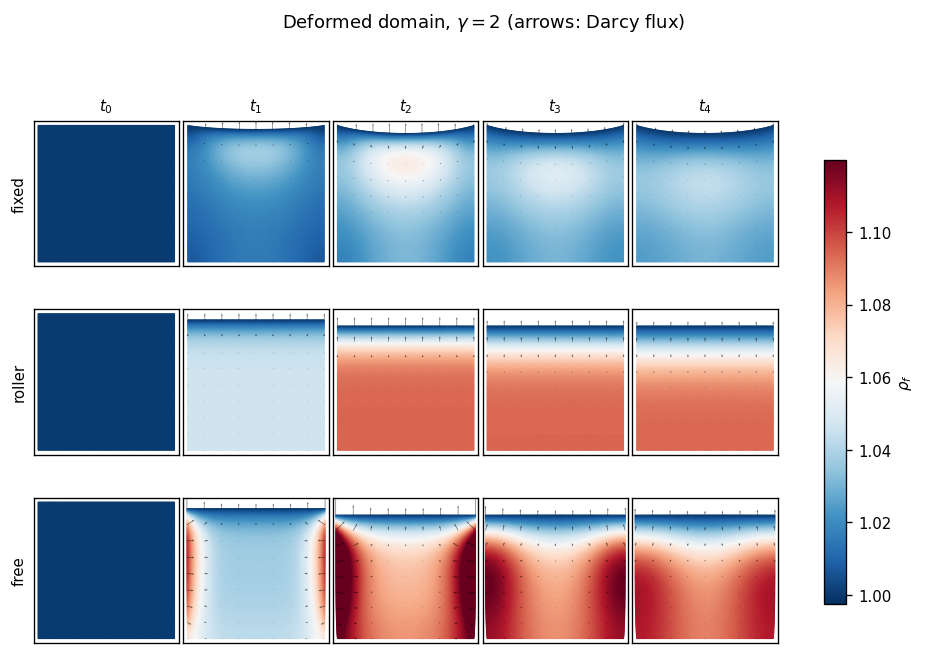

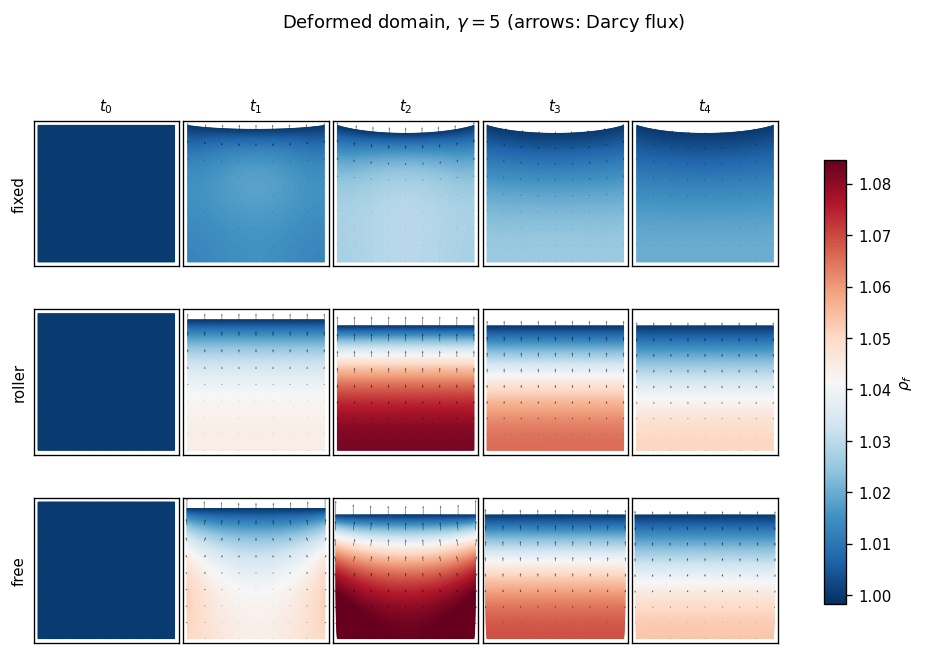

In [6]:
import re

def peek_field(pvtu_path):
    """Name of the one physical field a single-field .pvtu carries (run_footing.py
    writes u, q, rho, p, u_t to separate files at each save)."""
    names = re.findall(r'<PDataArray[^>]*Name="([^"]+)"', open(pvtu_path).read())
    for n in names:
        if n not in ("vtkOriginalPointIds", "vtkGhostType", "vtkOriginalCellIds"):
            return n
    return None

def read_pvtu(path, field):
    """Return (points, triangles, values) for `field` from a .pvtu file."""
    import vtk
    from vtk.util.numpy_support import vtk_to_numpy
    r = vtk.vtkXMLPUnstructuredGridReader(); r.SetFileName(path); r.Update()
    g = r.GetOutput()
    pts = vtk_to_numpy(g.GetPoints().GetData())[:, :2]
    conn = vtk_to_numpy(g.GetCells().GetConnectivityArray()).reshape(-1, 3)
    pd = g.GetPointData()
    arr = None
    for i in range(pd.GetNumberOfArrays()):
        if pd.GetArrayName(i) == field:
            arr = vtk_to_numpy(pd.GetArray(i))
    return pts, conn, arr

def find_frames(cfg_dir, n_times=5):
    """u, q and rho are written at fixed offsets within each save (see
    run_footing.py); pick n_times evenly spaced (u, q, rho) triples, however many
    saves are actually present."""
    import glob
    files = sorted(glob.glob(os.path.join(cfg_dir, "solution*.pvtu")))
    if not files:
        raise FileNotFoundError(f"no .pvtu under {cfg_dir}")
    by_field = {}
    for f in files:
        idx = int(os.path.basename(f)[len("solution"):-len(".pvtu")])
        by_field.setdefault(peek_field(f), {})[idx] = f
    u_files, q_files, rho_files = (by_field.get(k, {}) for k in ("u", "q", "rho"))
    triples = sorted((i, u_files[i], q_files[i + 1], rho_files[i + 2]) for i in u_files
                      if (i + 1) in q_files and (i + 2) in rho_files)
    if not triples:
        raise FileNotFoundError(f"no matching u/q/rho triples under {cfg_dir}")
    if len(triples) == 1:
        return triples * n_times
    return [triples[round(k * (len(triples) - 1) / (n_times - 1))] for k in range(n_times)]

K_APPROX    = 128     # footing mesh resolution, for quiver subsampling
QUIV_STRIDE = 16       # sample every QUIV_STRIDE-th CG1 vertex (~8x8 arrows)
QUIV_FRAC   = 0.07     # longest quiver arrow spans this fraction of the domain
PAD         = 0.02     # axis margin, tight enough that the free-side lateral
                        # bulge is visible instead of swamped by a large margin

def load_panel(u_path, q_path, rho_path):
    """Physical-scale deformed CG1 mesh + rho, and a subsampled Darcy-flux quiver,
    for one (config, saved-time) frame."""
    pts_rho, tris, rho = read_pvtu(rho_path, "rho")
    pts_u, _, u = read_pvtu(u_path, "u")
    _, _, q = read_pvtu(q_path, "q")

    # u/q live on CG2 (vertices + edge midpoints); rho lives on CG1 (vertices only),
    # an exact coordinate subset of the CG2 nodes -- match by position rather than
    # interpolate across the two meshes.
    key = {(round(x, 8), round(y, 8)): j for j, (x, y) in enumerate(pts_u)}
    idx_at_rho = np.array([key[(round(x, 8), round(y, 8))] for x, y in pts_rho])
    disp = u[idx_at_rho, :2]
    q_at_rho = q[idx_at_rho, :2]

    xy = pts_rho + disp   # physical scale, no amplification

    ix = np.round(pts_rho[:, 0] * K_APPROX).astype(int)
    iy = np.round(pts_rho[:, 1] * K_APPROX).astype(int)
    mask = (ix % QUIV_STRIDE == 0) & (iy % QUIV_STRIDE == 0)

    return xy, tris, rho, xy[mask], q_at_rho[mask]

def plot_deformed(gamma, n_times=5):
    from matplotlib.tri import Triangulation

    # --- load every panel once, to fix shared colour/quiver scales and axis limits ---
    panels = {}
    all_rho, all_xy, all_qmag = [], [], []
    for s, lab, _, _ in SIDES:
        cfg_dir = os.path.join(VTK_ROOT, f"{s}_g{gamma}")
        for k, (_, u_path, q_path, rho_path) in enumerate(find_frames(cfg_dir, n_times)):
            panels[(s, k)] = load_panel(u_path, q_path, rho_path)
            xy, tris, rho, xyq, q = panels[(s, k)]
            all_rho.append(rho); all_xy.append(xy)
            all_qmag.append(np.hypot(q[:, 0], q[:, 1]))
    all_rho = np.concatenate(all_rho); all_xy = np.concatenate(all_xy)
    all_qmag = np.concatenate(all_qmag)

    rho_min, rho_max = np.percentile(all_rho, [1, 99])
    rho_min = min(rho_min, 1.0 - 0.02 * max(rho_max - 1.0, 1e-8))
    rho_max = max(rho_max, 1.0 + 0.02 * max(rho_max - 1.0, 1e-8))
    max_qmag = max(np.percentile(all_qmag, 99), 1e-10)
    quiver_scale = max_qmag / QUIV_FRAC

    # shared, symmetric square axis limits -- same physical size every panel
    xlim = (all_xy[:, 0].min() - PAD, all_xy[:, 0].max() + PAD)
    ylim = (all_xy[:, 1].min() - PAD, all_xy[:, 1].max() + PAD)
    xc, yc = 0.5*(xlim[0]+xlim[1]), 0.5*(ylim[0]+ylim[1])
    half = max(0.5*(xlim[1]-xlim[0]), 0.5*(ylim[1]-ylim[0]))
    xlim, ylim = (xc-half, xc+half), (yc-half, yc+half)

    fig, axes = plt.subplots(len(SIDES), n_times, figsize=(2.0*n_times, 2.0*len(SIDES)),
                             gridspec_kw={"wspace": 0.03, "hspace": 0.06})
    im = None
    for i, (s, lab, _, _) in enumerate(SIDES):
        for k in range(n_times):
            xy, tris, rho, xyq, q = panels[(s, k)]
            ax = axes[i, k]
            tri = Triangulation(xy[:, 0], xy[:, 1], tris)
            im = ax.tripcolor(tri, rho, cmap="RdBu_r", vmin=rho_min, vmax=rho_max,
                              shading="gouraud")
            if max_qmag > 1e-12:
                ax.quiver(xyq[:, 0], xyq[:, 1], q[:, 0], q[:, 1],
                          scale=quiver_scale, scale_units="xy", angles="xy",
                          width=0.004, headwidth=3, headlength=4, headaxislength=3.5,
                          color="k", alpha=0.65)
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xticks([]); ax.set_yticks([])
            if i == 0: ax.set_title(f"$t_{{{k}}}$", fontsize=9)
            if k == 0: ax.set_ylabel(lab, fontsize=9)
    fig.colorbar(im, ax=axes, shrink=0.8, label=r"$\rho_f$")
    fig.suptitle(rf"Deformed domain, $\gamma={gamma}$ (arrows: Darcy flux)", y=1.01)
    plt.show()


if VTK_ROOT and os.path.isdir(VTK_ROOT):
    for gamma in GAMMAS:          # Figures 6, 7, 8
        plot_deformed(gamma)
else:
    print("VTK_ROOT is not set to an existing directory - skipping Figures 6-8.\n"
          "Generate the snapshots with:\n"
          "    python run_footing.py configs/footing_clamped_g1.txt   (etc., 9 configs)\n"
          "then set PF_VTK_ROOT to the resulting output/footing directory.")